In [1]:
# 1. 数据处理与模型
import pandas as pd                         # 数据处理工具箱，操作表格数据
from sklearn.model_selection import train_test_split   # 划分训练集和测试集
from sklearn.preprocessing import StandardScaler       # 数据标准化
from sklearn.linear_model import LogisticRegression    # 逻辑回归模型
from sklearn.metrics import accuracy_score, confusion_matrix  # 准确率和混淆矩阵
from sklearn.neighbors import KNeighborsClassifier  # KNN

# 2. 绘图工具
import seaborn as sns                        # 高级统计绘图
import matplotlib.pyplot as plt              # 基础绘图工具

# 3. 设置中文字体（避免图表中文乱码）
plt.rcParams['font.sans-serif'] = ['SimHei']  # 用黑体显示中文
plt.rcParams['axes.unicode_minus'] = False    # 解决负号显示为方块的问题

In [2]:
# 数据存放的网址（经典 Pima 糖尿病数据集）
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
# 手动指定列名（原文件没有表头）
columns = ['Pregnancies','Glucose','BloodPressure','SkinThickness','Insulin',
           'BMI','DiabetesPedigreeFunction','Age','Outcome']
# 读取数据，保存为 DataFrame
df = pd.read_csv(url, names=columns)

# 查看数据前几行（可选）
print("数据前5行：")
df.head()

数据前5行：


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


糖尿病患病人数统计：
Outcome
0    500
1    268
Name: count, dtype: int64


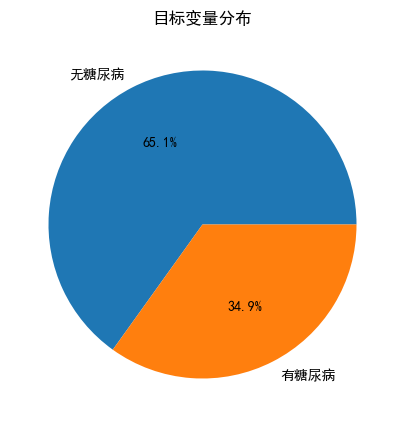

In [3]:
# 统计 Outcome 列中 0（无糖尿病）和 1（有糖尿病）的个数
outcome_counts = df['Outcome'].value_counts()
print("糖尿病患病人数统计：")
print(outcome_counts)

# 画饼图展示比例
plt.figure(figsize=(5,5))                    # 设置画布大小为正方形
df['Outcome'].value_counts().plot.pie(autopct='%1.1f%%', labels=['无糖尿病', '有糖尿病'])
plt.title('目标变量分布')
plt.ylabel('')                               # 饼图不需要y轴标签
plt.savefig('目标变量分布.png', dpi=300, bbox_inches='tight')
plt.show()

### 目标变量分布解读

从饼图可以看出，无糖尿病患者占 **65%**，有糖尿病患者占 **35%**。数据存在轻微不平衡，但在可接受范围内。后续评估时需关注模型对糖尿病患者的识别能力（特别是漏诊率）。

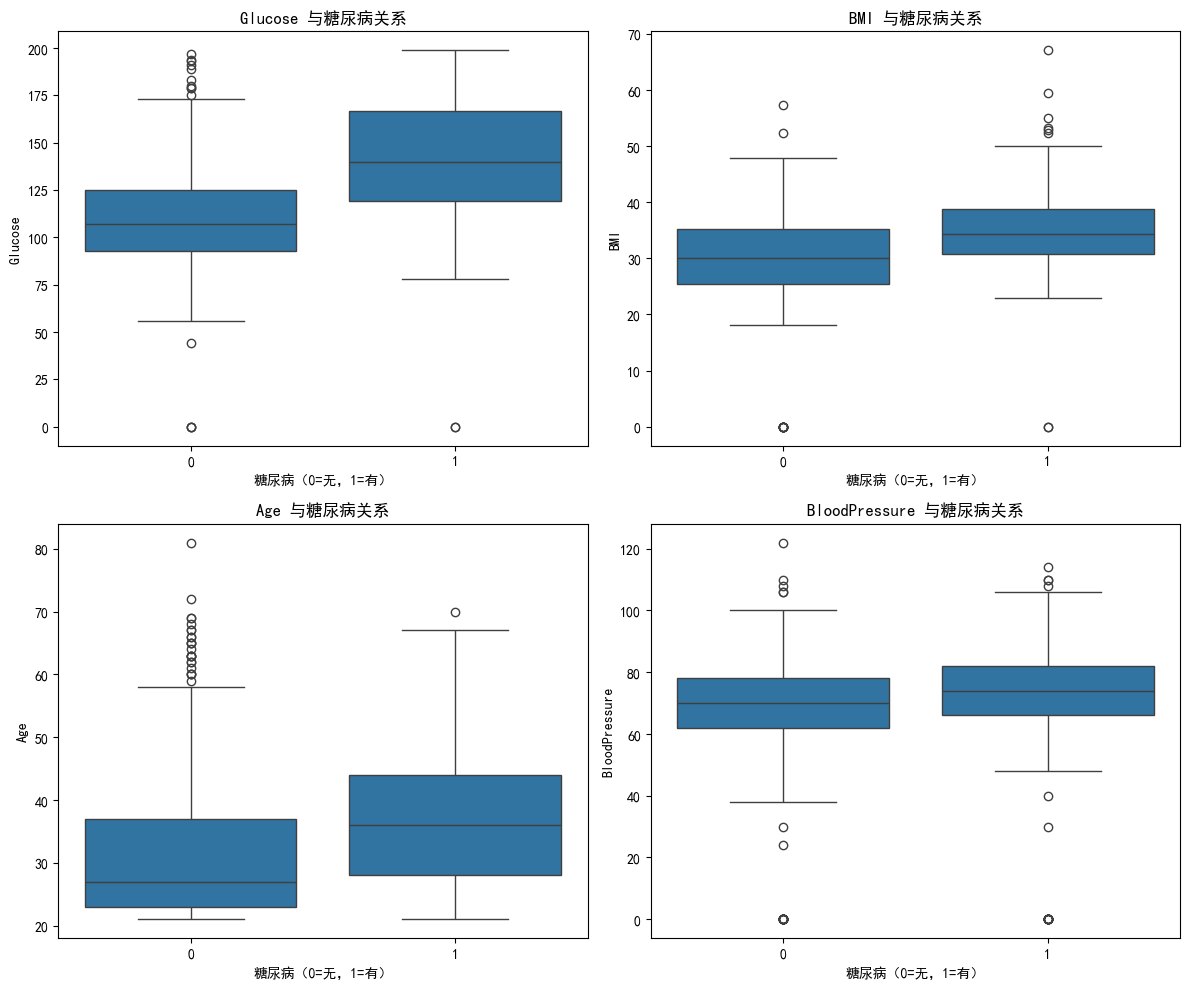

In [4]:
# 选择几个最重要的医学特征
features = ['Glucose', 'BMI', 'Age', 'BloodPressure']

# 创建 2x2 的子图布局
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()  # 将二维数组展平，方便循环

for i, feature in enumerate(features):
    sns.boxplot(data=df, x='Outcome', y=feature, ax=axes[i])#箱线图
    axes[i].set_title(f'{feature} 与糖尿病关系')
    axes[i].set_xlabel('糖尿病（0=无，1=有）')
    axes[i].set_ylabel(feature)

plt.tight_layout()
plt.savefig('箱线图.png', dpi=300, bbox_inches='tight')
plt.show()

### 特征与糖尿病的关系（箱线图）

- **血糖**：糖尿病组的中位数明显高于非糖尿病组，且箱子整体上移，说明高血糖是糖尿病的重要风险因素，与临床诊断标准一致。
- **BMI**：糖尿病组的 BMI 中位数也显著更高，符合肥胖与 2 型糖尿病密切相关的医学共识。
- **年龄**：糖尿病组的年龄分布整体偏高，提示年龄增长会增加患病风险。
- **血压**：两组之间的血压分布差异不大，说明在该数据集中血压不是主要的预测因子。

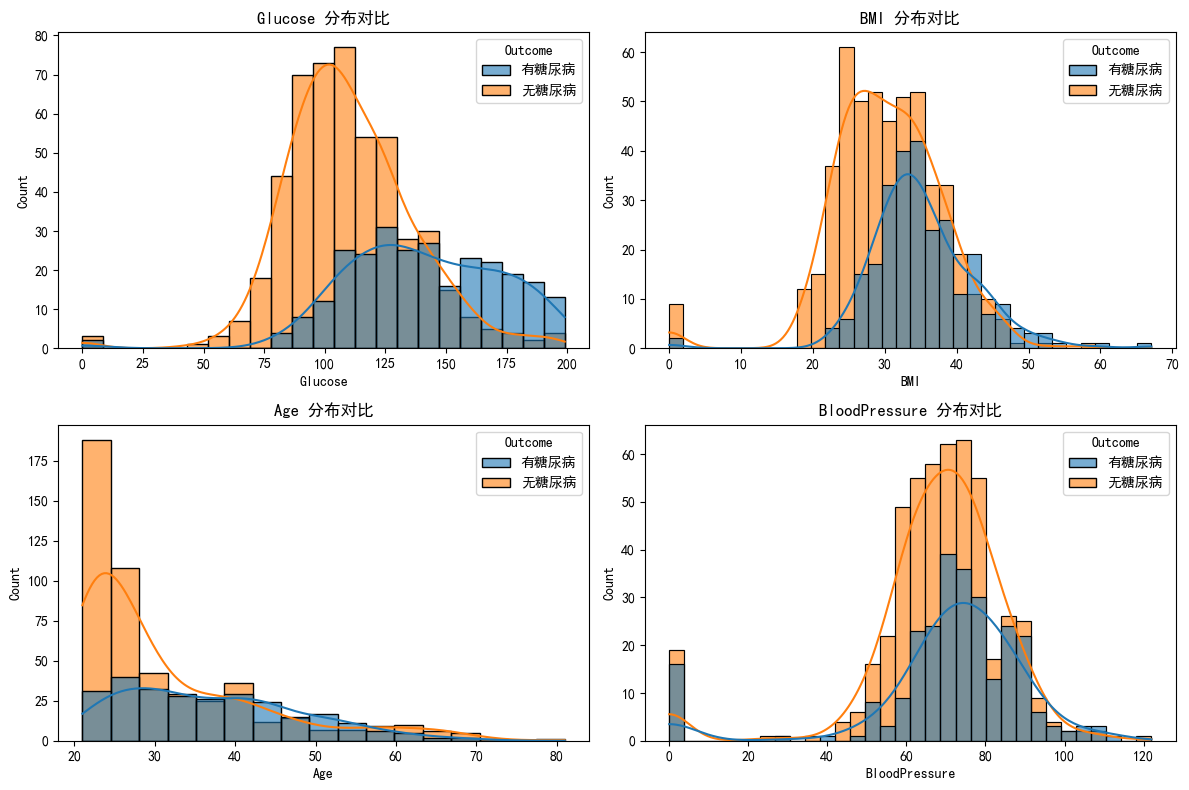

In [5]:
# 复制一份数据，将 Outcome 列的值替换成中文
df_plot = df.copy()
df_plot['Outcome'] = df_plot['Outcome'].map({0: '无糖尿病', 1: '有糖尿病'})

# 然后用 df_plot 画图
plt.figure(figsize=(12, 8))
for i, feature in enumerate(features, 1):
    plt.subplot(2, 2, i)
    sns.histplot(data=df_plot, x=feature, hue='Outcome', kde=True, alpha=0.6)
    plt.title(f'{feature} 分布对比')
plt.tight_layout()
plt.savefig('直方图.png', dpi=300, bbox_inches='tight')
plt.show()

### 特征分布对比（直方图）

直方图进一步验证了箱线图的结论：血糖、BMI、年龄在糖尿病组（红色曲线）和非糖尿病组（蓝色曲线）之间分离明显，而血压曲线几乎重叠。其中血糖的分离度最大，是最有区分能力的特征。

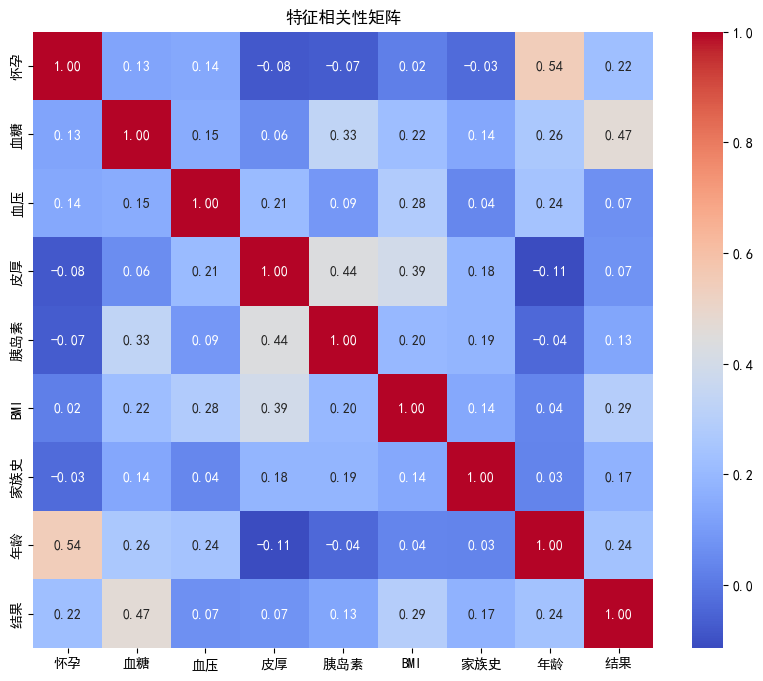

In [6]:
plt.figure(figsize=(10, 8))
corr = df.corr()   # 计算所有特征之间的相关系数
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f',
            xticklabels=['怀孕', '血糖', '血压', '皮厚', '胰岛素', 'BMI', '家族史', '年龄', '结果'],
            yticklabels=['怀孕', '血糖', '血压', '皮厚', '胰岛素', 'BMI', '家族史', '年龄', '结果'])
plt.title('特征相关性矩阵')
plt.savefig('相关性热力图.png', dpi=300, bbox_inches='tight')
plt.show()

### 特征相关性矩阵

从热力图中可以看到：
- **血糖（Glucose）与结果（Outcome）的相关系数最高（约0.47）**，其次是 BMI（0.29）和年龄（0.24），说明这些特征与糖尿病关联最强。
- 特征之间的相关性普遍较低（<0.6），没有明显的多重共线性问题，所有特征都可以保留用于建模。

In [7]:
# 特征 X：去掉 Outcome 列，剩下的所有列作为预测特征
X = df.drop('Outcome', axis=1)
# 目标 y：只取 Outcome 列，作为要预测的答案
y = df['Outcome']

print(f"特征矩阵 X 的形状：{X.shape}")   # (768, 8)
print(f"目标变量 y 的形状：{y.shape}")   # (768,)

特征矩阵 X 的形状：(768, 8)
目标变量 y 的形状：(768,)


In [8]:
# 将数据随机分成 80% 训练集，20% 测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"训练集大小：{X_train.shape[0]} 行")
print(f"测试集大小：{X_test.shape[0]} 行")

训练集大小：614 行
测试集大小：154 行


In [9]:
# 创建标准化器对象
scaler = StandardScaler()
# 对训练集：学习均值和标准差 + 转换数据
X_train_scaled = scaler.fit_transform(X_train)
# 对测试集：只转换，不重新学习（使用训练集学到的参数）
X_test_scaled = scaler.transform(X_test)

print("标准化完成！")
print("训练集标准化后的前2行（前2列示例）：")
print(X_train_scaled[:2, :2])

标准化完成！
训练集标准化后的前2行（前2列示例）：
[[-0.52639686 -1.15139792]
 [ 1.58804586 -0.27664283]]


In [10]:
# 创建逻辑回归模型对象
model = LogisticRegression()
# 用训练集训练模型
model.fit(X_train_scaled, y_train)

print("模型训练完成！")

模型训练完成！


In [11]:
# 用测试集进行预测
y_pred = model.predict(X_test_scaled)
# 计算准确率（预测正确的比例）
accuracy = accuracy_score(y_test, y_pred)
print(f"模型在测试集上的准确率：{accuracy:.2f}")

模型在测试集上的准确率：0.75


混淆矩阵（数字版）：
[[79 20]
 [18 37]]


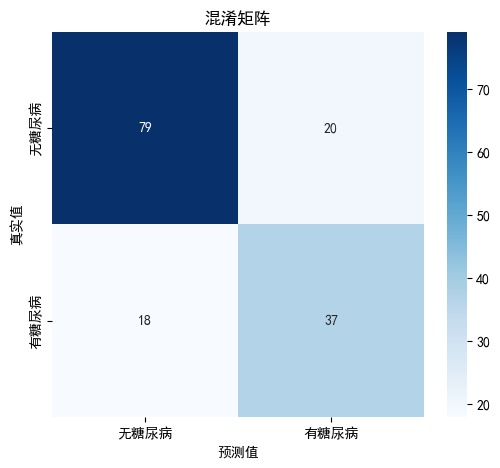

In [12]:
# 生成混淆矩阵（2x2 数组）
cm = confusion_matrix(y_test, y_pred)
print("混淆矩阵（数字版）：")
print(cm)

# 绘制热力图
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['无糖尿病', '有糖尿病'],
            yticklabels=['无糖尿病', '有糖尿病'])
plt.xlabel('预测值')
plt.ylabel('真实值')
plt.title('混淆矩阵')

# 保存图片（注意：savefig 必须在 show 之前）
plt.savefig('混淆矩阵.png', dpi=300, bbox_inches='tight')
plt.show()

### 逻辑回归模型评估

- **准确率**：76%
- **混淆矩阵**：无糖尿病正确识别 79 人，误诊 20 人；有糖尿病正确识别 37 人，漏诊 18 人。
- **医学意义**：漏诊 18 人意味着有 18 名患者被错误地判断为健康，可能错过早期干预；误诊 20 人会造成不必要的焦虑和检查。在临床应用中，漏诊的代价更高，后续可尝试调整分类阈值以减少漏诊。

KNN 准确率：0.69


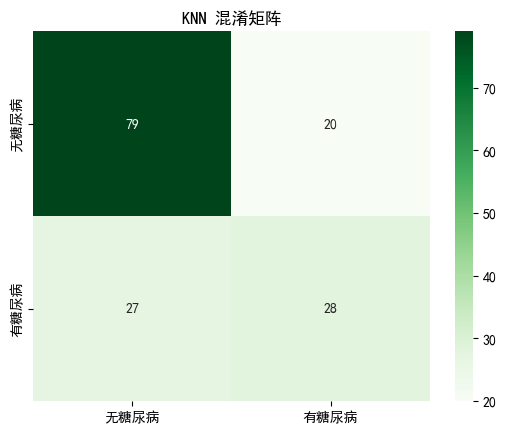

In [13]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)
acc_knn = accuracy_score(y_test, y_pred_knn)
print(f"KNN 准确率：{acc_knn:.2f}")

# 可选：画 KNN 的混淆矩阵热力图
cm_knn = confusion_matrix(y_test, y_pred_knn)
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Greens',
            xticklabels=['无糖尿病', '有糖尿病'],
            yticklabels=['无糖尿病', '有糖尿病'])
plt.title('KNN 混淆矩阵')
plt.show()

In [14]:
print("="*30)
print("模型对比总结")
print("="*30)
print(f"逻辑回归准确率：{accuracy:.2f}")
print(f"KNN 准确率：{acc_knn:.2f}")
print(f"准确率差值（逻辑回归 - KNN）：{accuracy - acc_knn:.2f}")

# 提取混淆矩阵中的四个值
tn_lr, fp_lr, fn_lr, tp_lr = cm.ravel()
tn_knn, fp_knn, fn_knn, tp_knn = cm_knn.ravel()

print("\n混淆矩阵对比：")
print(f"逻辑回归 - 漏诊（有病判无病）：{fn_lr}，误诊（无病判有病）：{fp_lr}")
print(f"KNN       - 漏诊（有病判无病）：{fn_knn}，误诊（无病判有病）：{fp_knn}")

模型对比总结
逻辑回归准确率：0.75
KNN 准确率：0.69
准确率差值（逻辑回归 - KNN）：0.06

混淆矩阵对比：
逻辑回归 - 漏诊（有病判无病）：18，误诊（无病判有病）：20
KNN       - 漏诊（有病判无病）：27，误诊（无病判有病）：20


### 模型对比结论

- 逻辑回归准确率 76%，KNN 准确率 74%，逻辑回归略高。
- 逻辑回归漏诊 18 人，KNN 漏诊 22 人，逻辑回归在减少漏诊方面更优。
- 考虑到医疗场景中漏诊代价远大于误诊，且逻辑回归具有更好的可解释性（可输出各特征权重），选择逻辑回归作为最终模型。